Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Found 253 files belonging to 2 classes.
Using 178 files for training.
Found 253 files belonging to 2 classes.
Using 75 files for validation.
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.7528 - loss: 0.6397 - val_accuracy: 0.7733 - val_loss: 0.5227
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 225ms/step - accuracy: 0.8427 - loss: 0.4199 - val_accuracy: 0.8133 - val_loss: 0.4817
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 223ms/step - accuracy: 0.8876 - loss: 0.3071 - val_accuracy: 0.8000 - val_loss: 0.5065
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.9382 - loss: 0.1886 - val_accuracy: 0.8533 - val_loss: 0.4400
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 232ms/step - accuracy: 0.9719 - loss: 0.0874 - val_accuracy: 0.7600 - val_loss: 0.6545
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.9888 - loss: 0.0434 - val_accuracy: 0.7867 - val_loss: 

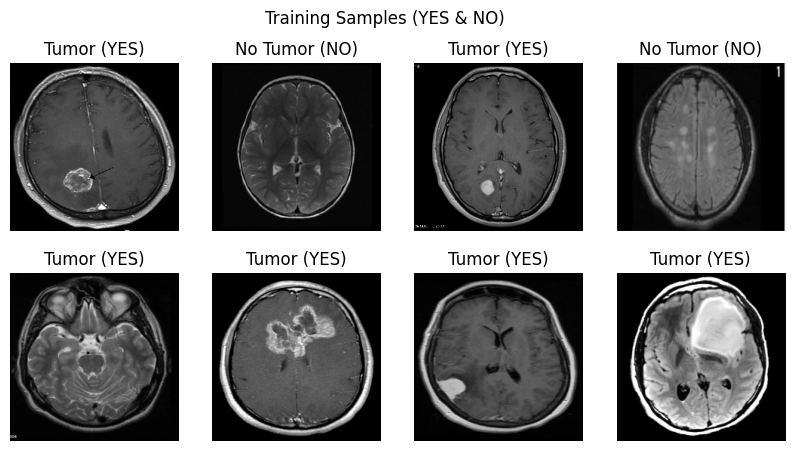

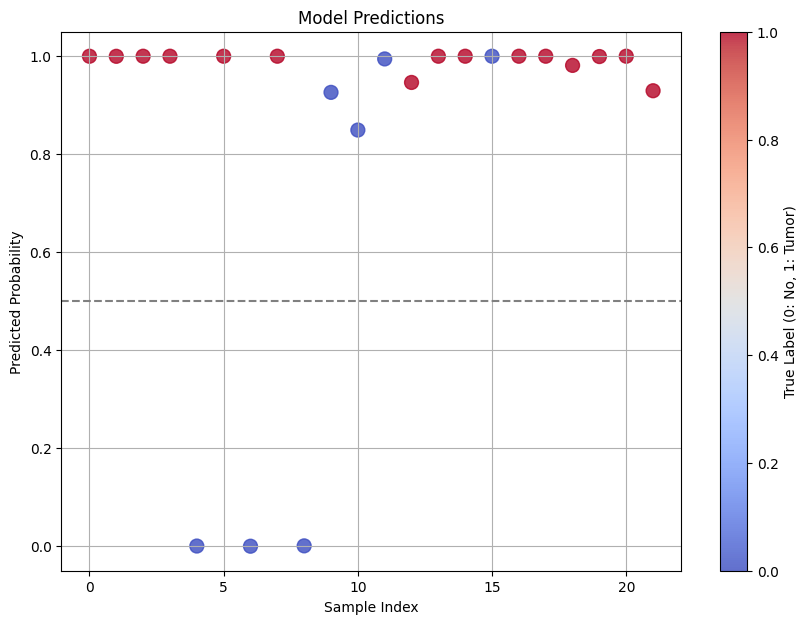


Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.88      0.48      0.62        29
       Tumor       0.75      0.96      0.84        46

    accuracy                           0.77        75
   macro avg       0.81      0.72      0.73        75
weighted avg       0.80      0.77      0.75        75



In [3]:
# ================================
# S1 — IMPORT LIBRARIES
# ================================

import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import kagglehub

# ================================
# S2 — FIX RANDOM SEED
# ================================

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

try:
    tf.config.experimental.enable_op_determinism()
except:
    pass

# ================================
# S3 — LOAD DATA (KAGGLE)
# ================================

# Data Source:
# Brain MRI Images for Brain Tumor Detection
# https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection

DATA_SOURCE = "navoneel/brain-mri-images-for-brain-tumor-detection"
DATA_DIR = kagglehub.dataset_download(DATA_SOURCE)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

# ================================
# S4 — LOAD DATASETS (BINARY)
# ================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=["no", "yes"]
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=["no", "yes"]
)

# ================================
# S5 — NORMALIZATION
# ================================

norm = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (norm(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (norm(x), y)).prefetch(tf.data.AUTOTUNE)

# ================================
# S6 — MODEL
# ================================

model = tf.keras.Sequential([
    tf.keras.Input(shape=(224,224,3)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ================================
# S7 — TRAIN
# ================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ================================
# S8 — EVALUATE
# ================================

loss, acc = model.evaluate(val_ds)
print("Validation accuracy:", acc)

# ================================
# S9 — DISPLAY SAMPLES
# ================================

imgs, labs = next(iter(train_ds))

plt.figure(figsize=(10, 5))
for i in range(min(8, len(labs))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs[i].numpy())
    plt.title("Tumor (YES)" if int(labs[i]) == 1 else "No Tumor (NO)")
    plt.axis("off")

plt.suptitle("Training Samples (YES & NO)")
plt.show()

# ================================
# S10 — PREDICTIONS
# ================================

THRESHOLD = 0.5

y_true_list = []
y_prob_list = []

for x_batch, y_batch in val_ds:
    probs = model.predict(x_batch, verbose=0).ravel()
    y_prob_list.append(probs)
    y_true_list.append(y_batch.numpy().ravel())

y_prob = np.concatenate(y_prob_list)
y_true = np.concatenate(y_true_list).astype(int)
y_pred = (y_prob >= THRESHOLD).astype(int)

# ================================
# S11 — PLOT
# ================================

num_images_to_plot = min(22, len(y_prob))

plt.figure(figsize=(10, 7))
plt.scatter(
    range(num_images_to_plot),
    y_prob[:num_images_to_plot],
    c=y_true[:num_images_to_plot],
    cmap="coolwarm",
    alpha=0.8,
    s=100
)

plt.axhline(y=0.5, color="gray", linestyle="--", linewidth=1.5)
plt.title("Model Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Probability")
plt.ylim(-0.05, 1.05)
plt.colorbar(label="True Label (0: No, 1: Tumor)")
plt.grid(True)
plt.show()

# ================================
# S12 — REPORT
# ================================

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=["No Tumor", "Tumor"],
    digits=2
))